In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

"First, I imported the required libraries. Pandas is used for data handling, NumPy for numerical operations, Matplotlib and Seaborn for visualization, and StandardScaler for feature scaling before clustering."
Explanation

import pandas as pd

Pandas is used to load, clean, and analyze datasets.
pd is just a short name for Pandas.

import numpy as np

NumPy is used for numerical calculations and array operations.

import matplotlib.pyplot as plt

Used for creating graphs and charts.

import seaborn as sns

Used to create attractive statistical visualizations.

from sklearn.preprocessing import StandardScaler

StandardScaler scales numerical features so they are on the same scale.
This is important because clustering algorithms use distance calculations.

In [4]:
file_path = r"C:\Users\Poornima\OneDrive\Desktop\VS_Sample\venv\Assignments\Mall_Clustering_Project_Assignment8\mall_customer_spend.xlsx"

df = pd.read_excel(file_path)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Stores the location of our Excel file.
r means raw string, which helps Python understand Windows backslashes (\).
Reads the Excel file.
Stores the data inside a DataFrame called df.
Displays the first 5 rows.
Used to check whether the data loaded correctly.

Task 1 – Data Exploration & Preprocessing.
Note:For clustering, we need to identify customer groups based on behavior, not on ID numbers.

In [7]:
#Task1.1 Load dataset
df.shape #tells us the size of the dataset. and it give number of rows and columns in the dataset.

(200, 5)

Presentation Explanation:

"I checked the shape of the dataset to understand how many customer records and features are available before performing clustering."
200 customers, 5 columns

In [9]:
#Task 1.2 – Check Column Names
df.columns #features in the dataset&decide which columns are useful for clustering

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

"I checked the column names to understand the available features. CustomerID is only an identifier, so it is not useful for clustering. I selected customer-related attributes such as age, income, and spending score for creating meaningful customer segments."

In [10]:
#Task 1.3 – Check Data Types
df.dtypes

CustomerID                int64
Genre                       str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Important observation:

For clustering algorithms like K-Means, Hierarchical, and DBSCAN:

They calculate distance between customers.
Distance calculation works with numerical values.
Text values cannot be directly used.
Age ✅ Numerical → Can use
Annual Income ✅ Numerical → Can use
Spending Score ✅ Numerical → Can use
Genre ⚠️ Categorical → Need encoding if we decide to include it
CustomerID ❌ Not useful → Remove

Presentation Explanation:

"I checked the data types to understand the nature of each feature. Most features are numerical, but Genre is a categorical feature. Since clustering algorithms work based on distance calculations, categorical values need transformation before use."

In [ ]:
#Task 1.4 – Check Missing Values
df.isnull().sum() #check for missing values in the dataset, because Missing values can affect clustering results.

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Presentation Explanation:

"I checked for missing values to ensure the dataset quality before applying clustering algorithms."

What this means:
There are no missing values in the dataset.
Every customer record has complete information.
We do not need any missing value treatment.
#We will remove It is just an identification number and  not describe customer behaviour 

"I checked for missing values using the isnull() function. The result showed zero missing values in all columns, so the dataset is complete and ready for further preprocessing."

In [ ]:
#Task 1.5 – Select relevant features for clustering
#"Group customers based on their demographics and spending behavior."
#We need features that represent customer behavior.

"Why did you not include Genre?"
"Genre is a categorical feature. Since the main objective was to segment customers based on spending behavior and purchasing patterns, I selected numerical features like age, annual income, and spending score. These features directly influence customer groups and work better with distance-based clustering algorithms."

In [12]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
#Task 1.6 – Scale Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler #Imports the scaling method from Scikit-learn.

In [14]:
scaler = StandardScaler() #Creates a StandardScaler object.

X_scaled = scaler.fit_transform(X)

X_scaled[:5] #Shows the first 5 scaled rows.

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

Presentation Explanation:

"Before applying clustering algorithms, I standardized the numerical features using StandardScaler because clustering algorithms are distance-based. Scaling ensures that all features contribute equally."

In [ ]:
#Task 2.1 – Import K-Means Library

In [15]:
from sklearn.cluster import KMeans

sklearn → Scikit-learn library used for machine learning.
cluster → Module containing clustering algorithms.
KMeans → The algorithm we are going to use for customer segmentation.
Explanation:
"I imported the KMeans algorithm from Scikit-learn's clustering module. This algorithm helps group customers into different segments based on similarities in their features."

In [ ]:
random_state=10 #Now we will create another K-Means model with a different random state.

In [17]:
#Task 2.2 (Continued) – Change Random Initialization
kmeans_random2 = KMeans(n_clusters=5, random_state=50)
kmeans_random2.fit(X_scaled)
labels_2 = kmeans_random2.labels_
labels_2[:10]

array([0, 1, 0, 1, 0, 1, 0, 1, 4, 1], dtype=int32)

Creates another K-Means model.
Same number of clusters (5).
But different initial centroid selection because random_state changed.
Trains the second model using the same customer data.
Stores the cluster assignments from the second model.
What we are checking:
random_state = 10
random_state = 50
If the labels are different: t shows the Random Initialization Trap.

Presentation Explanation:

"I changed the random initialization value and observed that the cluster assignments can change. This demonstrates that initial centroid selection can affect K-Means results. To reduce this issue, K-Means++ initialization is used."

In [23]:
random_state = 10

In [24]:
random_state = 50

In [27]:
kmeans_random1 = KMeans(n_clusters=5, random_state=10)

kmeans_random1.fit(X_scaled)

labels_1 = kmeans_random1.labels_

labels_1[:10]

array([1, 3, 1, 3, 1, 3, 1, 3, 2, 3], dtype=int32)

In [28]:
kmeans_random2 = KMeans(n_clusters=5, random_state=50)

kmeans_random2.fit(X_scaled)

labels_2 = kmeans_random2.labels_

labels_2[:10]

array([0, 1, 0, 1, 0, 1, 0, 1, 4, 1], dtype=int32)

Conclusion: Random Initialization Trap Demonstrated
"K-Means starts by randomly selecting initial centroids. Different starting points can produce different cluster assignments. This is called the random initialization trap."

Presentation Explanation:

"To demonstrate the random initialization trap, I trained two K-Means models with the same number of clusters but different random states. The cluster assignments changed, showing that initial centroid selection can affect the final result. To reduce this problem, K-Means++ initialization is used."

In [29]:
#Task 2.3 – Elbow Method to Find Optimal Number of Clusters
inertia_values = []

"I created an empty list to store the inertia values generated for different numbers of clusters. These values are used to plot the Elbow Method graph."

In [30]:
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

"I applied K-Means for different values of K ranging from 1 to 10. For each cluster value, I calculated inertia and stored the results. These values are used to identify the elbow point."

In [31]:
inertia_values

[599.9999999999999,
 389.3861889564372,
 295.4562449213557,
 205.22514747675913,
 169.89149793438585,
 134.35277477401493,
 121.38935022502874,
 113.72723000071338,
 102.13623844329253,
 92.55027231838784]

What do we understand from this?
As K increases:
Inertia decreases ✅
Because more clusters mean customers are divided into smaller groups.
But our goal is not to choose the highest K.
We need to find where the decrease becomes slower.
That point is called the Elbow Point.

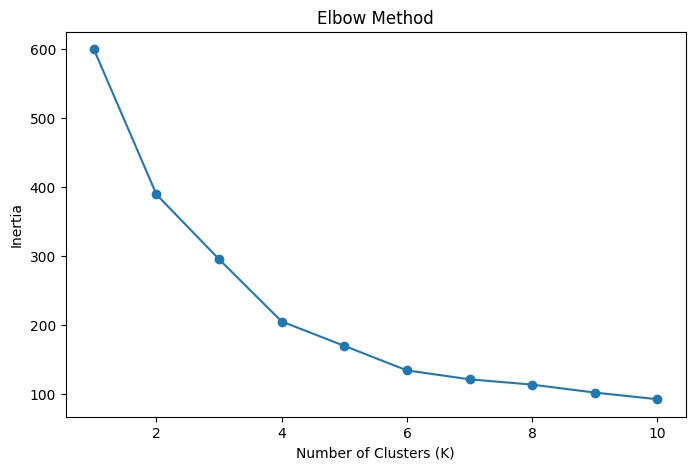

In [ ]:
#Plot Elbow Graph
plt.figure(figsize=(8,5)) #Creates the graph size.

plt.plot(range(1,11), inertia_values, marker='o') #X-axis → Number of clusters,Y-axis → Inertia values,marker='o' shows points.

plt.xlabel("Number of Clusters (K)") #Adds labels.
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show() #Displays the graph.

In [ ]:
#Observing the Elbow Graph

From your graph:
K = 1 to K = 4 → Inertia decreases rapidly
After K = 5 → The decrease becomes slower

Presentation Explanation:

"I plotted the inertia values against different numbers of clusters. The elbow point helps identify the optimal number of clusters where adding more clusters provides limited improvement."

In [ ]:
#Optimal Number of Clusters = 5

In [33]:
n_clusters = 5

How to Explain in Presentation:

"I used the Elbow Method to identify the optimal number of clusters. I calculated inertia values for different values of K from 1 to 10 and plotted them. The graph shows that the rate of decrease slows down after K=5, so I selected 5 as the optimal number of customer segments."

In [ ]:
#Task 2.4 – Build Final K-Means Model

In [34]:
final_kmeans = KMeans(n_clusters=5, random_state=42)
final_kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 3)","[

n_clusters=5 → Creates 5 customer groups based on Elbow Method.
random_state=42 → Gives reproducible results.
fit() → Learns patterns and creates clusters.
Your Final K-Means model is created successfully.

In [ ]:
Task 2.4 – Build Final K-Means Model

In [35]:
final_kmeans = KMeans(n_clusters=5, random_state=42)
final_kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 3)","[

In [36]:
cluster_labels = final_kmeans.labels_
cluster_labels[:10]

array([2, 2, 3, 2, 2, 2, 3, 2, 0, 2], dtype=int32)

final_kmeans → your final K-Means model after selecting the optimal number of clusters.
.labels_ → extracts the cluster assigned to every customer.
cluster_labels[:10] → displays the first 10 customer cluster assignments.

In [ ]:
#Task 3 – Hierarchical Clustering,
#Task 3.1: Create Dendrogram

In [37]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

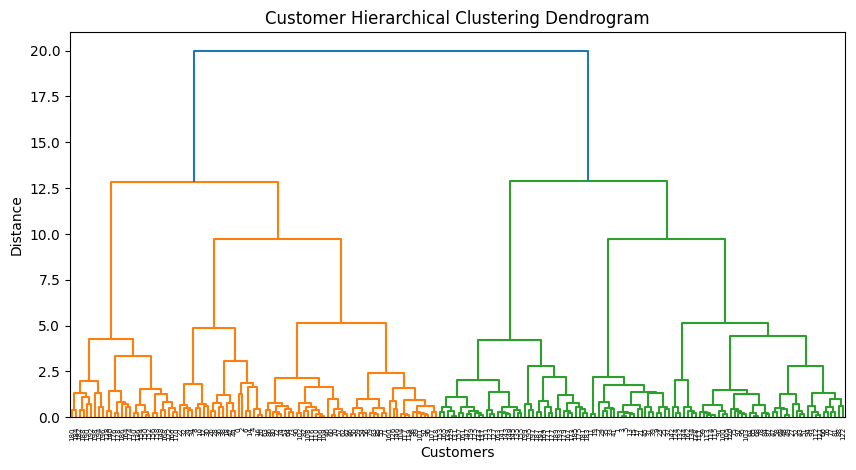

In [38]:
# Creating linkage using Ward method
hierarchy = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,5))
dendrogram(hierarchy)

plt.title("Customer Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

presentation:

"First, I created a dendrogram to understand how customers are grouped together. Hierarchical clustering starts with individual customers and gradually combines similar customers into groups. The distance shown on the Y-axis tells how different the groups are."

In [39]:
#Task 3.2: Apply Agglomerative Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

In [40]:
# Creating hierarchical clustering model
hierarchical_model = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

# Assigning cluster labels
hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

# Display first 10 cluster labels
hierarchical_labels[:10]

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0])

Presentation explanation:

"After analyzing the dendrogram, I applied Agglomerative Hierarchical Clustering with 5 clusters. The model groups customers based on similarity. Each customer receives a cluster label representing their customer segment."

In [ ]:
##Task 3.2:Compare cluster formation with K-Means
hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

In [42]:
print("K-Means Cluster Labels:")
print(cluster_labels[:10])

print("\nHierarchical Cluster Labels:")
print(hierarchical_labels[:10])

K-Means Cluster Labels:
[2 2 3 2 2 2 3 2 0 2]

Hierarchical Cluster Labels:
[4 0 4 0 4 0 4 0 4 0]


presentation:

"I compared the cluster assignments from K-Means and Hierarchical Clustering. Both algorithms identify customer groups, but the cluster numbers are different because each algorithm follows a different clustering approach. K-Means forms clusters based on distance from cluster centers, whereas Hierarchical Clustering creates clusters by merging similar customers step by step."

Important point to mention:

The cluster numbers do not represent the same meaning across algorithms.

Example:

K-Means Cluster 2 ≠ Hierarchical Cluster 2 necessarily.
Cluster labels are just names assigned by the algorithm.

conclusion:
"Both clustering methods successfully segmented customers. K-Means provides clear partitioning using centroids, while Hierarchical Clustering provides a tree-based view of customer relationships through the dendrogram."

#Task 4 – DBSCAN Clustering

In [ ]:
#Step4.1: Apply DBSCAN Model

In [43]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [44]:
# Creating DBSCAN model
dbscan_model = DBSCAN(eps=0.5, min_samples=5)

# Predicting clusters
dbscan_labels = dbscan_model.fit_predict(X_scaled)

# Display first 10 labels
dbscan_labels[:10]

array([-1,  0, -1,  0, -1,  0, -1, -1, -1,  0])

presentation:

"DBSCAN is a density-based clustering algorithm. It groups customers based on the density of data points. Unlike K-Means, DBSCAN does not require the number of clusters before training. The value -1 represents noise points, which are customers that do not belong to any cluster."

In [ ]:
#Step 4.2: Check Number of Clusters and Noise Points

In [45]:
# Count clusters
clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Count noise points
noise = list(dbscan_labels).count(-1)

print("Number of clusters:", clusters)
print("Number of noise points:", noise)

Number of clusters: 6
Number of noise points: 60


Meaning:
6 clusters → DBSCAN identified 6 groups of customers based on data density.
60 noise points → 60 customers were considered unusual points that did not strongly belong to any cluster.
In DBSCAN, noise points are represented by the label -1.

Presentation explanation:

"DBSCAN identified customer groups based on the density of data points. It automatically detected 6 clusters without specifying the number of clusters in advance. It also identified 60 noise points, which represent customers with different spending patterns compared to other groups."

In [ ]:
#Step4.3: Compare DBSCAN with K-Means and Hierarchical Clustering

In [46]:
print("K-Means Clusters:")
print(cluster_labels[:10])

print("\nHierarchical Clusters:")
print(hierarchical_labels[:10])

print("\nDBSCAN Clusters:")
print(dbscan_labels[:10])

K-Means Clusters:
[2 2 3 2 2 2 3 2 0 2]

Hierarchical Clusters:
[4 0 4 0 4 0 4 0 4 0]

DBSCAN Clusters:
[-1  0 -1  0 -1  0 -1 -1 -1  0]


Conclusion (for your report):

"DBSCAN successfully identified customer groups and detected noise points. Compared with K-Means and Hierarchical Clustering, DBSCAN provides additional information by identifying customers with uncommon spending behavior. This can help businesses analyze unique customer segments."

Presentation explanation:

"I compared three clustering algorithms: K-Means, Hierarchical Clustering, and DBSCAN. K-Means and Hierarchical methods assign every customer to a cluster, whereas DBSCAN can identify unusual customers as noise points. This helps businesses detect unique customer behavior patterns."

In [ ]:
#Task 5 – Dimensionality Reduction
#Step 5.1: Apply PCA

In [47]:
from sklearn.decomposition import PCA

In [48]:
# Reduce features into 2 components
pca = PCA(n_components=2)

# Transform scaled data
pca_data = pca.fit_transform(X_scaled)

# View first 5 rows
pca_data[:5]

array([[-0.61572002, -1.76348088],
       [-1.66579271, -1.82074695],
       [ 0.33786191, -1.67479894],
       [-1.45657325, -1.77242992],
       [-0.03846521, -1.66274012]])

Explanation:

"PCA converts the original features into two new components that capture maximum information from the dataset. These components can be used for visualization."

In [ ]:
#Step 5.2: Visualize PCA Result

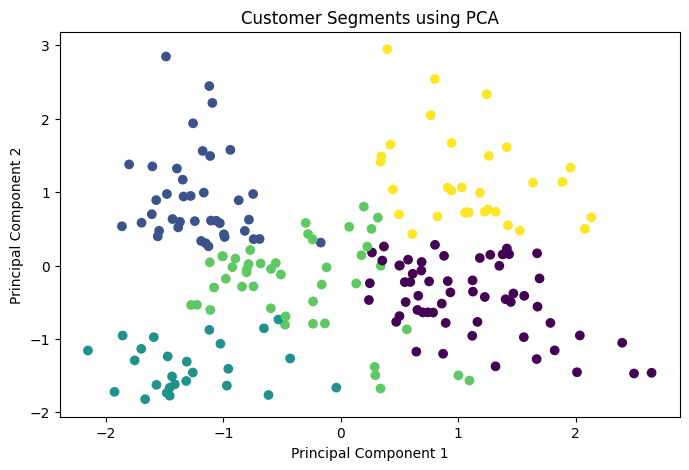

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=cluster_labels
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

PCA Observation:

"The PCA plot reduced the customer data into two principal components and visualized the customer segments. The plot shows 5 different colored groups, representing the clusters identified by K-Means. This indicates that PCA helps in understanding the separation and distribution of customer groups in a lower-dimensional space."

Presentation explanation:

"The PCA plot shows customer groups in two dimensions. Different colors represent different K-Means clusters. PCA helps us visually understand whether customers are naturally separated into groups."

In [53]:
from sklearn.manifold import TSNE

In [52]:

# Creating t-SNE model
tsne = TSNE(n_components=2, random_state=42)

# Transform data into 2 dimensions
tsne_data = tsne.fit_transform(X_scaled)

# View first 5 rows
tsne_data[:5]

array([[-1.9998555, -5.802341 ],
       [-7.6690936, -3.958828 ],
       [-1.0382714, -7.492694 ],
       [-7.2389755, -4.064827 ],
       [-1.037457 , -5.9822497]], dtype=float32)

t-SNE has converted your customer data into 2 dimensions.
The two new dimensions are used only for visualization.
Customers with similar patterns will appear closer together on the t-SNE plot.

Presentation explanation:

"I applied t-SNE to create a two-dimensional representation of customer data. Unlike PCA, t-SNE focuses on preserving similarities between nearby data points. It helps visualize whether customers with similar behavior form separate groups."

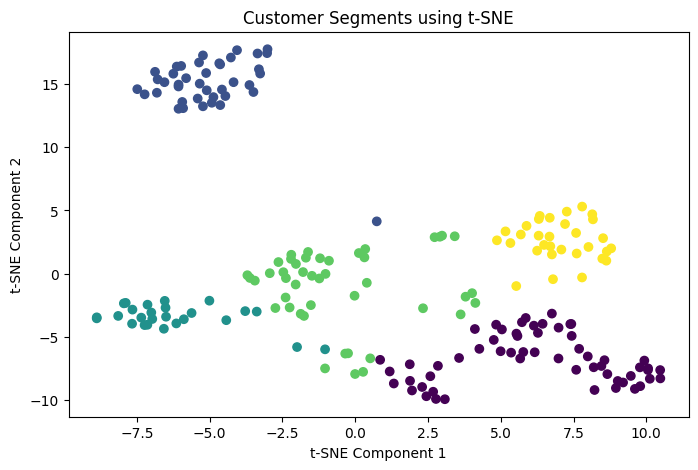

In [54]:
plt.figure(figsize=(8,5))

plt.scatter(
    tsne_data[:,0],
    tsne_data[:,1],
    c=cluster_labels
)

plt.title("Customer Segments using t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.show()

Your observation:

Total 5 color groups are visible.
One color group is clearly separated from the other 4 groups.
t-SNE is showing the local similarity pattern of customers more clearly.

You can write this in your assignment:

t-SNE Observation:

"The t-SNE visualization reduced the customer data into two dimensions and displayed 5 different customer groups. One cluster is clearly separated from the remaining groups, indicating that some customers have distinct spending behavior compared to others. t-SNE provides better visual separation of similar customer groups compared to PCA."

Task 5: PCA vs t-SNE Comparison

| PCA                                           | t-SNE                                           |
| --------------------------------------------- | ----------------------------------------------- |
| Reduces dimensions by creating new components | Reduces dimensions mainly for visualization     |
| Preserves maximum overall information         | Preserves similarity between nearby data points |
| Gives a general view of customer groups       | Shows clearer separation of similar groups      |
| Faster and suitable for larger datasets       | More useful for exploring complex patterns      |



In [ ]:
#Task 6 – Cluster Analysis
#Step 1: Add Cluster Labels to Dataset

In [55]:
# Add K-Means cluster labels to original data

df['Cluster'] = cluster_labels

# Display first 5 rows
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


Explanation for presentation:

"After performing clustering, I added the cluster labels back to the original dataset to analyze the characteristics of each customer group."

In [ ]:
#Step 2: Analyze Average Customer Characteristics

In [60]:
# Find average values for each cluster

# Add K-Means cluster labels to original dataset

df['Cluster'] = cluster_labels

# Calculate average values for each cluster
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,68.775862,55.275862,47.620690,41.706897
1,161.025000,32.875000,86.100000,81.525000
2,23.461538,25.769231,26.115385,74.846154
3,86.377778,26.733333,54.311111,40.911111
4,166.870968,44.387097,89.774194,18.483871


| Cluster |   Age | Annual Income (k$) | Spending Score | Customer Segment                           |
| ------- | ----: | -----------------: | -------------: | ------------------------------------------ |
| 0       | 55.27 |              47.62 |          41.70 | Average Income, Average Spending Customers |
| 1       | 32.87 |              86.10 |          81.52 | Premium / High Value Customers             |
| 2       | 25.76 |              26.11 |          74.84 | Young High Spending Customers              |
| 3       | 26.73 |              54.31 |          40.91 | Young Moderate Spending Customers          |
| 4       | 44.38 |              89.77 |          18.48 | High Income Low Spending Customers         |


"After clustering, I analyzed the characteristics of each customer group using average age, income, and spending score. Based on these values, I identified different customer segments with unique purchasing behaviors."

Final Project Conclusion 

"Using unsupervised learning techniques, customers were grouped into meaningful segments based on their demographic and spending behavior. K-Means, Hierarchical Clustering, and DBSCAN helped identify customer patterns. PCA and t-SNE provided visualization of these groups. These insights can help the mall design targeted marketing strategies, improve customer engagement, and increase sales."